In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

##Data Loading , Cleaning and Preprocessing

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML/project/4/Bank_Churn_Classification_Dataset.csv")
df.head()

,Unnamed: 0,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35


In [4]:
df.shape

(10000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10000 non-null  int64  
 1   CustomerID      10000 non-null  int64  
 2   Gender          10000 non-null  object 
 3   SeniorCitizen   10000 non-null  int64  
 4   Tenure          10000 non-null  int64  
 5   MonthlyCharges  10000 non-null  float64
 6   Contract        10000 non-null  object 
 7   PaymentMethod   10000 non-null  object 
 8   Churn           10000 non-null  int64  
 9   TotalCharges    10000 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
CustomerID,0
Gender,0
SeniorCitizen,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
Churn,0
TotalCharges,0


In [7]:
df=df.drop(["Unnamed: 0", "CustomerID"], axis=1)

In [8]:
df = pd.get_dummies(df, columns=["Gender","Contract","PaymentMethod"], drop_first=True)

##Data Visulization

/tmp/ipykernel_5903/1022443239.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3', ax=axes[0,1])
/tmp/ipykernel_5903/1022443239.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['No','Yes'])
/tmp/ipykernel_5903/1022443239.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2', ax=axes[0,2])
/tmp/ipykernel_5903/1022443239.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,2].set_xti

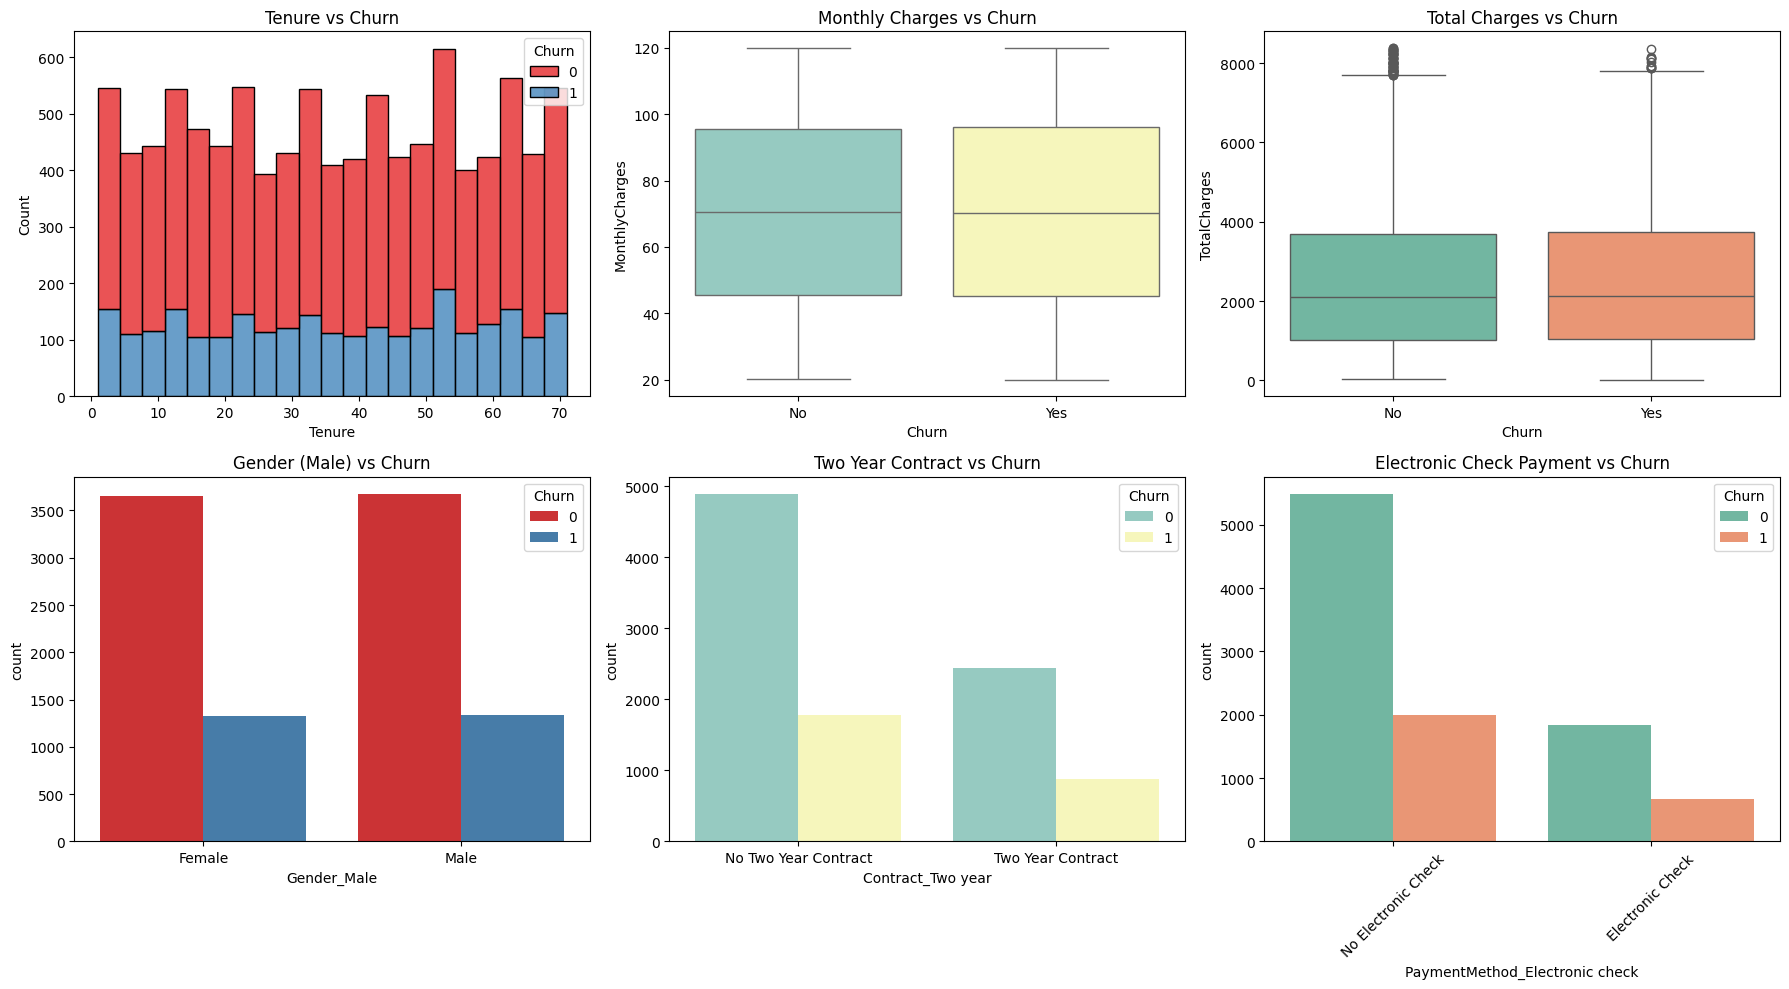

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Tenure vs Churn
sns.histplot(data=df, x='Tenure', hue='Churn', multiple='stack', palette='Set1', ax=axes[0,0])
axes[0,0].set_title('Tenure vs Churn')

# Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3', ax=axes[0,1])
axes[0,1].set_title('Monthly Charges vs Churn')
axes[0,1].set_xticklabels(['No','Yes'])

# Total Charges vs Churn
sns.boxplot(x='Churn', y='TotalCharges', data=df, palette='Set2', ax=axes[0,2])
axes[0,2].set_title('Total Charges vs Churn')
axes[0,2].set_xticklabels(['No','Yes'])

# Gender vs Churn
sns.countplot(x='Gender_Male', hue='Churn', data=df, palette='Set1', ax=axes[1,0])
axes[1,0].set_title('Gender (Male) vs Churn')
axes[1,0].set_xticklabels(['Female','Male'])

# Contract vs Churn
sns.countplot(x='Contract_Two year', hue='Churn', data=df, palette='Set3', ax=axes[1,1])
axes[1,1].set_title('Two Year Contract vs Churn')
axes[1,1].set_xticklabels(['No Two Year Contract','Two Year Contract'])

# Payment Method vs Churn
sns.countplot(x='PaymentMethod_Electronic check', hue='Churn', data=df, palette='Set2', ax=axes[1,2])
axes[1,2].set_title('Electronic Check Payment vs Churn')
axes[1,2].set_xticklabels(['No Electronic Check','Electronic Check'])
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

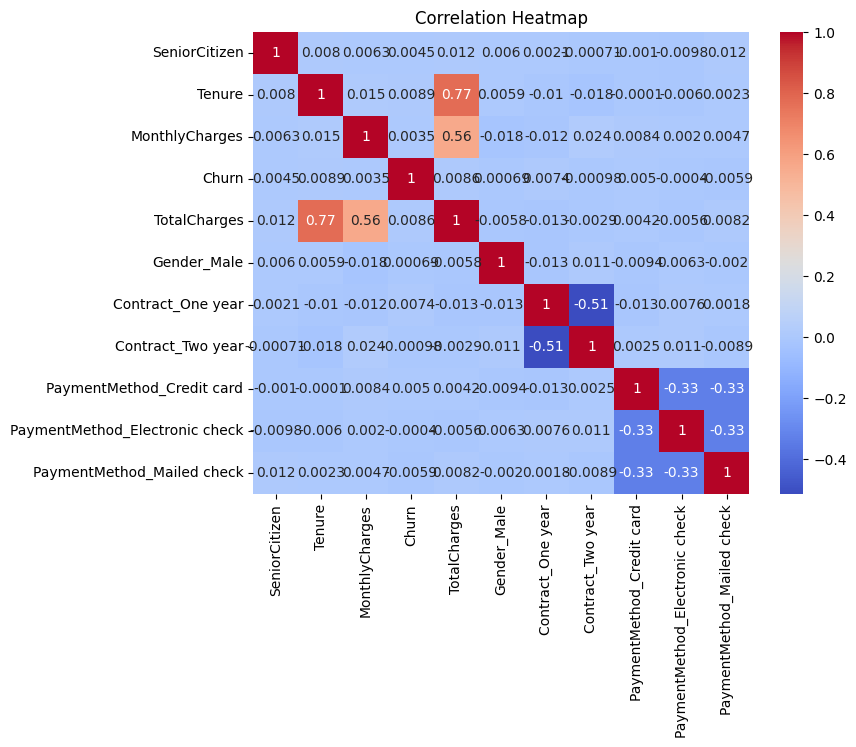

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##Feature Selection

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## training model

In [16]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##model Evaluation

In [17]:
y_pred = model.predict(X_test)

Accuracy: 0.697
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1472
           1       0.28      0.10      0.14       528

    accuracy                           0.70      2000
   macro avg       0.51      0.50      0.48      2000
weighted avg       0.62      0.70      0.64      2000



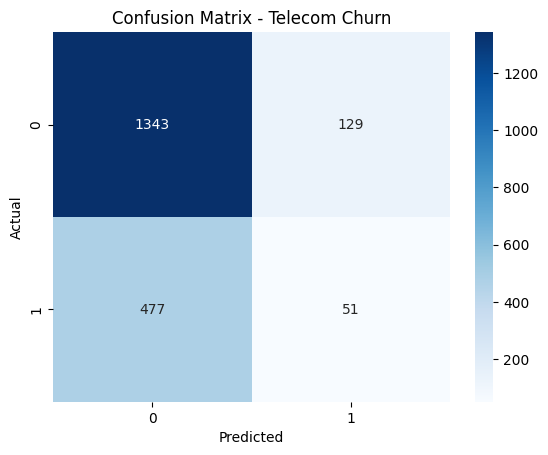

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Telecom Churn")
plt.show()

##saving model

In [21]:
pickle.dump(model, open("telecom_churn_model.pkl", "wb"))